In [1]:
# Raw Data Loading
import pandas as pd

red_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial' +\
                        '/master/dataset/winequality-red.csv'
white_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial' +\
                        '/master/dataset/winequality-white.csv'

red_wine = pd.read_csv(red_url, sep = ';')
white_wine = pd.read_csv(white_url, sep = ";")

In [2]:
red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
white_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
red_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
white_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [6]:
# 레드 와인과 화이트 와인을 합치기 전 color 컬럼 추가
red_wine['color'] = 1
white_wine['color'] = 0

wine = pd.concat([red_wine, white_wine])
wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 710.6 KB


In [7]:
wine['quality'].unique()

array([5, 6, 7, 4, 8, 3, 9], dtype=int64)

In [ ]:
# quality 데이터 분포 확인
import plotly.express as px

fig = px.histogram(wine, x='quality')

fig.update_layout(
    xaxis=dict(tickmode='linear',
               dtick=1,
               range=[2.5, 9.5])
)
fig.show()

In [13]:
# 두 와인 모두 5 ~ 7등급에 몰려있음
fig = px.histogram(wine,
                   x='quality',
                   color='color')

fig.update_layout(
    xaxis=dict(tickmode='linear',
               dtick=1,
               range=[2.5, 9.5])
)
fig.show()

In [15]:
# color 분류 모델 생성
import numpy as np
from sklearn.model_selection import train_test_split

x = wine.drop(['color'], axis=1)
y = wine['color']

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=13)
np.unique(y_train, return_counts=True)

(array([0, 1], dtype=int64), array([3913, 1284], dtype=int64))

In [16]:
# 훈련 셋과 테스트 셋 quailty 분포 차이
# 동일하게 잘 분리되었음
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Histogram(x=x_train['quality'],
                           name='Train'))
fig.add_trace(go.Histogram(x=x_test['quality'],
                           name='Test'))

fig.update_layout(
    barmode='overlay',
    xaxis=dict(tickmode='linear',
               dtick=1,
               range=[2.5, 9.5])
)
fig.update_traces(opacity=0.75)
fig.show()

In [17]:
# Decision Tree Classifier 학습
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(max_depth=2, random_state=13)
dtc.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=13)

In [18]:
# 평가
from sklearn.metrics import accuracy_score

pred_train = dtc.predict(x_train)
pred_test = dtc.predict(x_test)

print(f'Train ACC: {accuracy_score(y_train, pred_train)}')
print(f'Test ACC: {accuracy_score(y_test, pred_test)}')

Train ACC: 0.9553588608812776
Test ACC: 0.9569230769230769


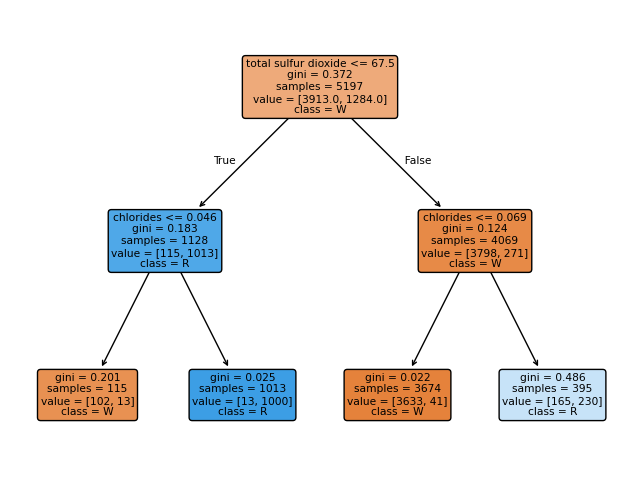

In [ ]:
# 분류에 중요한 feature 확인
import matplotlib.pyplot as plt
from sklearn import tree

fig = plt.figure(figsize=(8, 6))
_ = tree.plot_tree(dtc,
                  feature_names =list(x_train.columns),
                  class_names = ["W" , "R"],
                  rounded = True,
                  filled=True)

In [ ]:
# depth를 2로 설정했기 때문에 2개의 feature만 사용한 것을 볼 수 있다.
dict(zip(x_train.columns, dtc.feature_importances_))

{'fixed acidity': 0.0,
 'volatile acidity': 0.0,
 'citric acid': 0.0,
 'residual sugar': 0.0,
 'chlorides': 0.24230360549660776,
 'free sulfur dioxide': 0.0,
 'total sulfur dioxide': 0.7576963945033922,
 'density': 0.0,
 'pH': 0.0,
 'sulphates': 0.0,
 'alcohol': 0.0,
 'quality': 0.0}

In [ ]:
# 임의의 피쳐를 뽑아 Boxplot 그리기
# 각 피쳐마다 값의 범위가 다른 것을 볼 수 있음
fig = go.Figure()

fig.add_trace(go.Box(y=x['fixed acidity'],
                     name='fixed acidity'))
fig.add_trace(go.Box(y=x['chlorides'],
                     name='chlorides'))
fig.add_trace(go.Box(y=x['quality'],
                     name='quality'))

fig.show()

In [21]:
# 정규화 (MinMaxScaler, StandardScaler)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

mms = MinMaxScaler()
ss = StandardScaler()

mms.fit(x)
ss.fit(x)

x_mms = mms.transform(x)
x_ss = ss.transform(x)

In [22]:
x_mms_df = pd.DataFrame(x_mms, columns=x.columns)
x_ss_df = pd.DataFrame(x_ss, columns=x.columns)

In [23]:
# MinMaxScaler로 정규화된 데이터 확인
# 범위가 0 ~ 1로 변환된 것을 볼 수 있음
fig = go.Figure()

fig.add_trace(go.Box(y=x_mms_df['fixed acidity'], 
                     name='fixed acidity'))
fig.add_trace(go.Box(y=x_mms_df['chlorides'], 
                     name='chlorides'))
fig.add_trace(go.Box(y=x_mms_df['quality'], 
                     name='quality'))

fig.show()

In [25]:
# StandardScaler로 정규화된 데이터 확인
# 평균이 0, 표준편차가 1인 분포로 변환된 것을 볼 수 있음
fig = go.Figure()

fig.add_trace(go.Box(y=x_ss_df['fixed acidity'], 
                     name='fixed acidity'))
fig.add_trace(go.Box(y=x_ss_df['chlorides'], 
                     name='chlorides'))
fig.add_trace(go.Box(y=x_ss_df['quality'], 
                     name='quality'))

fig.show()

In [26]:
# MinMaxScaler로 정규화된 데이터로 학습 및 평가
x_train, x_test, y_train, y_test = train_test_split(x_mms_df,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=13)

dtc_mms = DecisionTreeClassifier(max_depth=2, random_state=13)
dtc_mms.fit(x_train, y_train)

pred_train_mms = dtc_mms.predict(x_train)
pred_test_mms = dtc_mms.predict(x_test)

print(f'Train Acc (scaled by MinMaxScaler): {accuracy_score(y_train, pred_train_mms)}')
print(f'Test Acc (scaled by MinMaxScaler): {accuracy_score(y_test, pred_test_mms)}')

Train Acc (scaled by MinMaxScaler): 0.9553588608812776
Test Acc (scaled by MinMaxScaler): 0.9569230769230769


In [27]:
# StandardScaler로 정규화된 데이터로 학습 및 평가
x_train, x_test, y_train, y_test = train_test_split(x_ss_df,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=13)

dtc_ss = DecisionTreeClassifier(max_depth=2, random_state=13)
dtc_ss.fit(x_train, y_train)

pred_train_ss = dtc_ss.predict(x_train)
pred_test_ss = dtc_ss.predict(x_test)

print(f'Train Acc (scaled by MinMaxScaler): {accuracy_score(y_train, pred_train_ss)}')
print(f'Test Acc (scaled by MinMaxScaler): {accuracy_score(y_test, pred_test_ss)}')

Train Acc (scaled by MinMaxScaler): 0.9553588608812776
Test Acc (scaled by MinMaxScaler): 0.9569230769230769


In [31]:
# 맛있는 와인, 맛없는 와인 분류하기
np.unique(wine['quality'])

array([3, 4, 5, 6, 7, 8, 9], dtype=int64)

In [32]:
wine['taste'] = [1 if grade > 5 else 0 for grade in wine['quality']]
wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   int64  
 13  taste                 6497 non-null   int64  
dtypes: float64(11), int64(3)
memory usage: 761.4 KB


In [33]:
# 와인 맛을 분류하는 모델 생성
x = wine.drop(['taste'], axis=1)
y = wine['taste']

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=13)

dtc = DecisionTreeClassifier(max_depth=2, random_state=13)
dtc.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=13)

In [34]:
# 왜 1이 나왔을까?
pred_train = dtc.predict(x_train)
pred_test = dtc.predict(x_test)

print(f'Train ACC: {accuracy_score(y_train, pred_train)}')
print(f'Test ACC: {accuracy_score(y_test, pred_test)}')

Train ACC: 1.0
Test ACC: 1.0


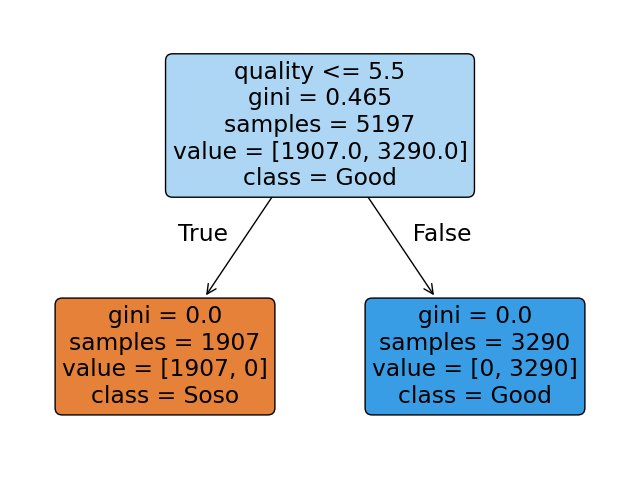

In [ ]:
# taste를 quality를 사용하여 만들었는데
# 학습에 quality를 다시 사용하여
# 단순히 quality만을 사용하여 100% 정확도 달성
fig = plt.figure(figsize=(8, 6))
_ = tree.plot_tree(dtc,
                   feature_names=list(x_train.columns),
                   class_names=['Soso', 'Good'],
                   rounded=True,
                   filled=True)

In [38]:
# quality 제외하고 다시 학습
x = wine.drop(['taste', 'quality'], axis=1)
y = wine['taste']

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=13)

dtc = DecisionTreeClassifier(max_depth=2, random_state=13)
dtc.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=13)

In [39]:
pred_train = dtc.predict(x_train)
pred_test = dtc.predict(x_test)

print(f'Train ACC: {accuracy_score(y_train, pred_train)}')
print(f'Test ACC: {accuracy_score(y_test, pred_test)}')

Train ACC: 0.7294593034442948
Test ACC: 0.7161538461538461


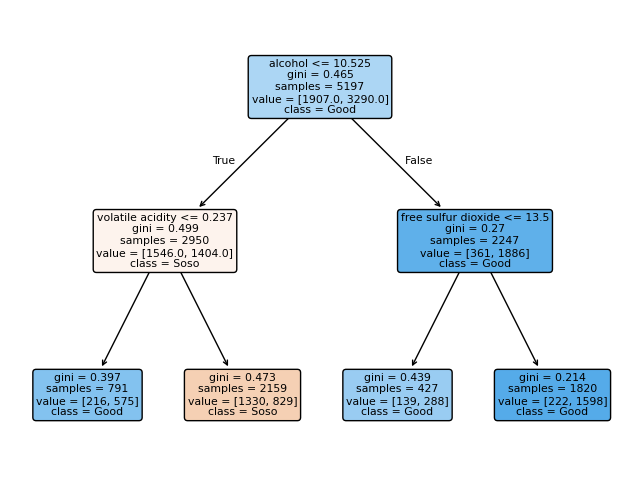

In [ ]:
# 이번엔 alcohol과 sulfur dioxide가 맛을 결정하는데 중요한 feature로 결정됨
# 과연 도수가 높다고 맛있는 와인일까?
fig = plt.figure(figsize=(8, 6))
_ = tree.plot_tree(dtc,
                   feature_names=list(x_train.columns),
                   class_names=['Soso', 'Good'],
                   rounded=True,
                   filled=True)

In [42]:
dict(zip(x_train.columns, dtc.feature_importances_))

{'fixed acidity': 0.0,
 'volatile acidity': 0.2714166536849971,
 'citric acid': 0.0,
 'residual sugar': 0.0,
 'chlorides': 0.0,
 'free sulfur dioxide': 0.057120460609986594,
 'total sulfur dioxide': 0.0,
 'density': 0.0,
 'pH': 0.0,
 'sulphates': 0.0,
 'alcohol': 0.6714628857050162,
 'color': 0.0}